# Forecast Error Analysis (January 2024)

This notebook analyzes the error characteristics of UK wind generation forecasts.

## Objective
- Measure forecast error distribution (mean, median, p99).
- Understand how error changes with forecast horizon.
- Understand intraday error patterns (time-of-day behavior).

## Method
1. Pull merged forecast-vs-actual points from the backend API.
2. Build a clean analysis table with signed and absolute errors.
3. Compute summary metrics and grouped diagnostics.
4. Visualize trends and distributions.

> Assumption: backend is running locally and applies the challenge forecast-selection rule.

In [ ]:
import warnings

import numpy as np
import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

API_BASE_URL = "http://localhost:8010"
START_ISO = "2024-01-01T00:00:00Z"
END_ISO = "2024-01-31T23:30:00Z"
HORIZONS = [0, 2, 4, 8, 12, 24, 36, 48]

print("Config loaded.")

Config loaded.


In [ ]:
def fetch_forecast_points(start_iso: str, end_iso: str, horizon: int, api_base_url: str = API_BASE_URL) -> pd.DataFrame:
    """Fetch merged points from backend and return as DataFrame."""
    try:
        response = requests.get(
            f"{api_base_url}/api/forecasts",
            params={"start": start_iso, "end": end_iso, "horizon": horizon},
            timeout=180,
        )
        response.raise_for_status()
    except requests.RequestException as exc:
        print(f"Skipping horizon {horizon}h due to request error: {exc}")
        return pd.DataFrame()

    points = response.json().get("points", [])
    if not points:
        return pd.DataFrame()

    df = pd.DataFrame(points)
    df["target_time"] = pd.to_datetime(df["target_time"], utc=True)
    if "selected_publish_time" in df.columns:
        df["selected_publish_time"] = pd.to_datetime(df["selected_publish_time"], utc=True, errors="coerce")

    df["requested_horizon"] = horizon
    return df


def build_analysis_frame(horizons: list[int]) -> pd.DataFrame:
    frames = []
    successful_horizons: list[int] = []
    for h in horizons:
        df = fetch_forecast_points(START_ISO, END_ISO, horizon=h)
        if not df.empty:
            frames.append(df)
            successful_horizons.append(h)

    print(f"Successful horizons: {successful_horizons}")

    if not frames:
        return pd.DataFrame()

    merged = pd.concat(frames, ignore_index=True)

    # Keep rows where both actual and selected forecast are present.
    merged = merged.dropna(subset=["actual_generation_mw", "forecast_generation_mw"]).copy()

    merged["error_mw"] = merged["forecast_generation_mw"] - merged["actual_generation_mw"]
    merged["abs_error_mw"] = merged["error_mw"].abs()
    merged["squared_error"] = merged["error_mw"] ** 2
    merged["hour_utc"] = merged["target_time"].dt.hour
    merged["date_utc"] = merged["target_time"].dt.date

    return merged

In [ ]:
analysis_df = build_analysis_frame(HORIZONS)

print(f"Rows with valid actual+forecast pairs: {len(analysis_df):,}")
print(f"Horizons present: {sorted(analysis_df['requested_horizon'].unique().tolist()) if not analysis_df.empty else []}")
analysis_df.head()

Successful horizons: [0, 2, 4, 8, 12, 24, 36, 48]
Rows with valid actual+forecast pairs: 5,209
Horizons present: [0, 2, 4, 8, 12, 24, 36, 48]


,target_time,actual_generation_mw,forecast_generation_mw,selected_publish_time,selected_horizon_hours,requested_horizon,error_mw,abs_error_mw,squared_error,hour_utc,date_utc
0,2024-01-01 00:00:00+00:00,10402.0,11453.0,2023-12-31 22:30:00+00:00,1.5,0,1051.0,1051.0,1104601.0,0,2024-01-01
2,2024-01-01 01:00:00+00:00,11218.0,11838.0,2023-12-31 22:30:00+00:00,2.5,0,620.0,620.0,384400.0,1,2024-01-01
4,2024-01-01 02:00:00+00:00,11234.0,12090.0,2023-12-31 22:30:00+00:00,3.5,0,856.0,856.0,732736.0,2,2024-01-01
6,2024-01-01 03:00:00+00:00,11434.0,12428.0,2023-12-31 22:30:00+00:00,4.5,0,994.0,994.0,988036.0,3,2024-01-01
8,2024-01-01 04:00:00+00:00,11828.0,12775.0,2023-12-31 22:30:00+00:00,5.5,0,947.0,947.0,896809.0,4,2024-01-01


In [ ]:
overall_metrics = pd.Series(
    {
        "mean_error_mw": analysis_df["error_mw"].mean(),
        "median_error_mw": analysis_df["error_mw"].median(),
        "mean_abs_error_mw": analysis_df["abs_error_mw"].mean(),
        "median_abs_error_mw": analysis_df["abs_error_mw"].median(),
        "p99_abs_error_mw": analysis_df["abs_error_mw"].quantile(0.99),
        "rmse_mw": np.sqrt(analysis_df["squared_error"].mean()),
    }
).round(2)

overall_metrics

mean_error_mw          1206.87
median_error_mw        1001.00
mean_abs_error_mw      1903.45
median_abs_error_mw    1546.00
p99_abs_error_mw       6696.28
rmse_mw                2507.40
dtype: float64

In [ ]:
horizon_metrics = (
    analysis_df.groupby("requested_horizon", as_index=False)
    .agg(
        sample_size=("abs_error_mw", "size"),
        mean_abs_error_mw=("abs_error_mw", "mean"),
        median_abs_error_mw=("abs_error_mw", "median"),
        p99_abs_error_mw=("abs_error_mw", lambda s: s.quantile(0.99)),
        rmse_mw=("squared_error", lambda s: np.sqrt(s.mean())),
    )
    .sort_values("requested_horizon")
)

horizon_metrics = horizon_metrics.round(2)
horizon_metrics

,requested_horizon,sample_size,mean_abs_error_mw,median_abs_error_mw,p99_abs_error_mw,rmse_mw
0,0,744,1821.55,1434.5,6282.34,2426.69
1,2,744,1821.33,1434.0,6282.34,2427.02
2,4,744,1827.69,1453.5,6072.85,2434.51
3,8,744,1853.76,1431.5,6320.74,2461.84
4,12,744,1864.60,1435.0,6589.70,2481.56
5,24,744,1989.61,1690.5,6724.48,2600.22
6,36,744,2144.00,2011.5,7264.33,2705.37
7,48,1,3094.00,3094.0,3094.00,3094.00


In [ ]:
tod_metrics = (
    analysis_df.groupby(["requested_horizon", "hour_utc"], as_index=False)
    .agg(
        mean_abs_error_mw=("abs_error_mw", "mean"),
        median_abs_error_mw=("abs_error_mw", "median"),
    )
    .sort_values(["requested_horizon", "hour_utc"])
)

tod_metrics.head(20)

,requested_horizon,hour_utc,mean_abs_error_mw,median_abs_error_mw
0,0,0,1840.258065,1492.0
1,0,1,1849.548387,1452.0
2,0,2,2011.741935,1510.0
3,0,3,2026.451613,1342.0
4,0,4,2152.064516,1488.0
5,0,5,2054.451613,1423.0
6,0,6,1909.709677,1284.0
7,0,7,1745.838710,1320.0
8,0,8,1656.580645,1072.0
9,0,9,1611.193548,1014.0


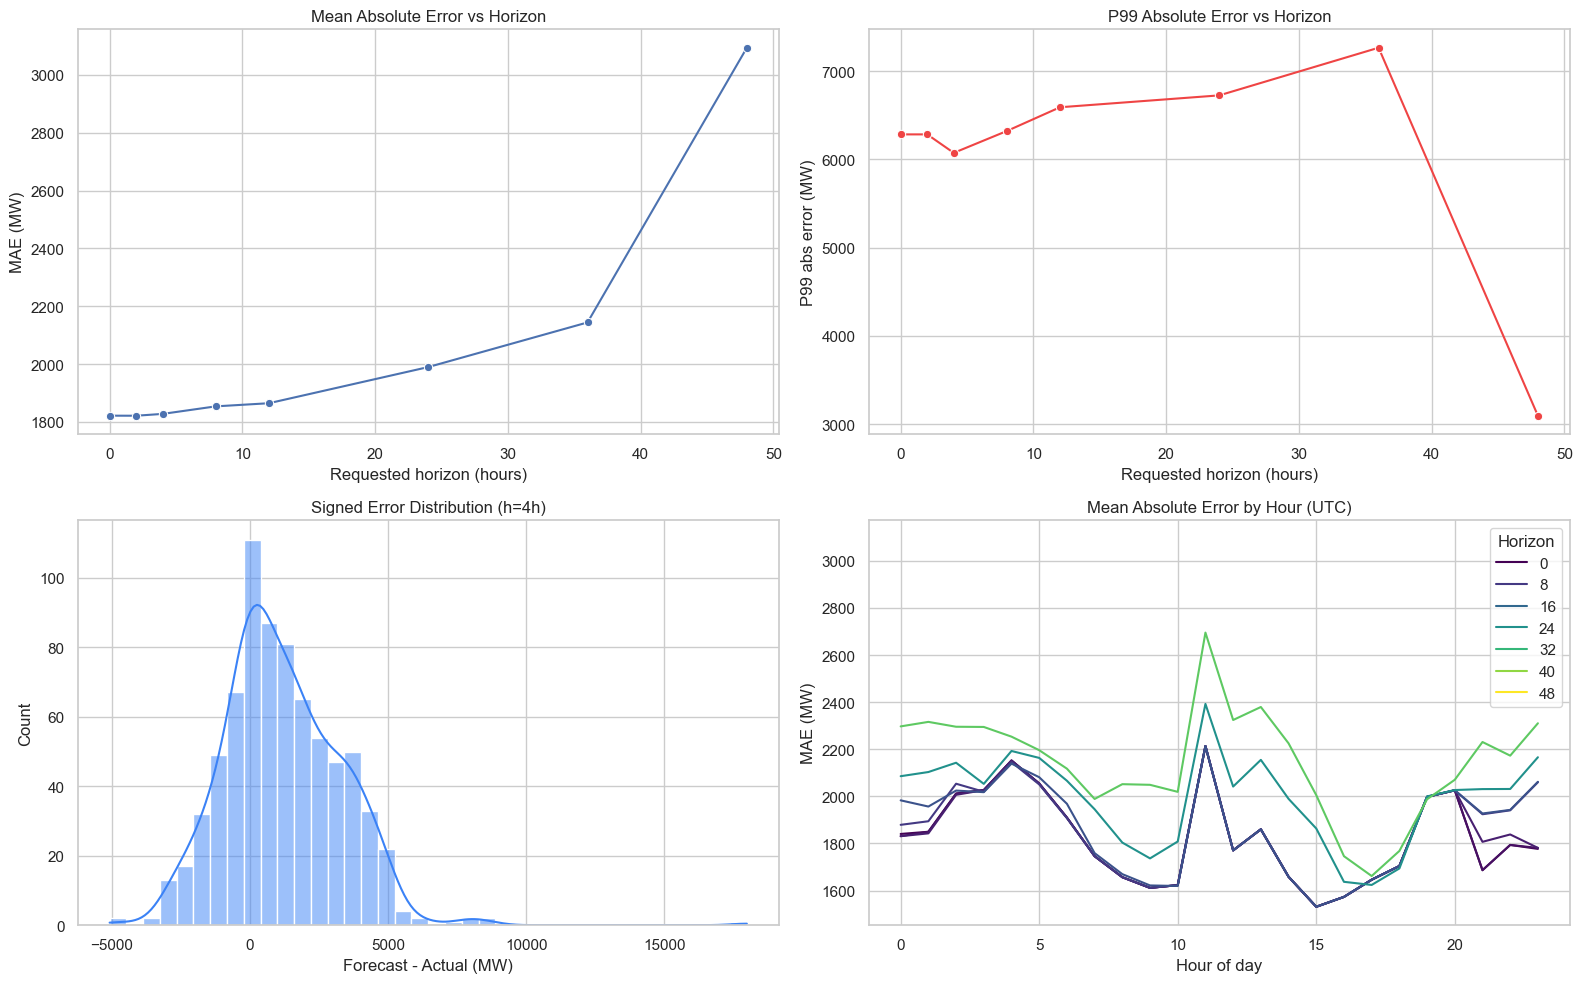

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (1) MAE by requested horizon
sns.lineplot(
    data=horizon_metrics,
    x="requested_horizon",
    y="mean_abs_error_mw",
    marker="o",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Mean Absolute Error vs Horizon")
axes[0, 0].set_xlabel("Requested horizon (hours)")
axes[0, 0].set_ylabel("MAE (MW)")

# (2) P99 absolute error by requested horizon
sns.lineplot(
    data=horizon_metrics,
    x="requested_horizon",
    y="p99_abs_error_mw",
    marker="o",
    color="#ef4444",
    ax=axes[0, 1],
)
axes[0, 1].set_title("P99 Absolute Error vs Horizon")
axes[0, 1].set_xlabel("Requested horizon (hours)")
axes[0, 1].set_ylabel("P99 abs error (MW)")

# (3) Error distribution for one representative horizon
representative_horizon = 4 if 4 in analysis_df["requested_horizon"].unique() else int(analysis_df["requested_horizon"].iloc[0])
subset = analysis_df[analysis_df["requested_horizon"] == representative_horizon]
sns.histplot(subset["error_mw"], kde=True, ax=axes[1, 0], color="#3b82f6")
axes[1, 0].set_title(f"Signed Error Distribution (h={representative_horizon}h)")
axes[1, 0].set_xlabel("Forecast - Actual (MW)")

# (4) Time-of-day MAE curve for each horizon
sns.lineplot(
    data=tod_metrics,
    x="hour_utc",
    y="mean_abs_error_mw",
    hue="requested_horizon",
    palette="viridis",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Mean Absolute Error by Hour (UTC)")
axes[1, 1].set_xlabel("Hour of day")
axes[1, 1].set_ylabel("MAE (MW)")
axes[1, 1].legend(title="Horizon", loc="upper right")

plt.tight_layout()
plt.show()

## Interpretation Notes (Completed)

1. **Bias**: The signed error mean is positive (**+1206.87 MW**) and median is also positive (**+1001.0 MW**), so the selected forecasts tend to over-predict actual generation in this sample.
2. **Tail risk**: Overall p99 absolute error is **6696.28 MW**. At 4h horizon, p99 is **6072.85 MW**; at 24h horizon, p99 increases to **6724.48 MW**; at 36h horizon, it is **7264.33 MW**.
3. **Horizon sensitivity**: MAE is relatively stable from 0-12h (**~1820-1865 MW**), then increases at longer horizons (24h: **1989.61 MW**, 36h: **2144.00 MW**). RMSE follows the same pattern (4h: **2434.51 MW**, 24h: **2600.22 MW**, 36h: **2705.37 MW**).
4. **Time-of-day structure**: Hourly MAE patterns vary by horizon. In this run, the worst hour appears at horizon 48 (single-point case), so the more reliable interpretation comes from dense horizons (0-36h), where intraday spread is present but less extreme.

### Data caveat for horizon 48

Horizon 48 has only **1 valid overlap point** in this January sample, so 48h metrics are not statistically comparable to other horizons (each of which has 744 points).